# https://scib-metrics.readthedocs.io/en/latest/notebooks/lung_example.html
## Setup
Check the environment, import dependencies, and set paths.

In [ ]:
import sys
print(sys.version)
print(sys.executable)
import importlib
print(importlib.util.find_spec("scbiot"))
import scbiot as scb


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
import torch
import os
import pandas as pd
import scbiot as scb
from scbiot.utils import set_seed

import harmonypy as hm
from umap import UMAP
# %pip install scib-metrics
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

set_seed(42)

from pathlib import Path
dir = Path(os.environ.get("SCBIOT_TUTORIALS_PATH", Path.cwd()))
print(dir)
parent_dir = dir.parent
print(parent_dir)


## Load
Read the lung atlas dataset from disk.

In [3]:
adata_path = f"{dir}/inputs/lung_atlas.h5ad"

adata = sc.read(
    adata_path,
    backup_url="https://figshare.com/ndownloader/files/24539942",
)


## Preprocess
Create semi-supervised labels and compute PCA features. Here, we randomly select 20% of cells as truly labeled and assign the remaining cells the label Unknown. For custom datasets, you can instead label high-confidence cells by thresholding marker-gene module scores at the 80th percentile, then propagate these seed labels to the remaining cells with the supBIOT method.

In [4]:
# ==== Make semi-supervised labels from true labels ====
# deps: numpy, pandas (AnnData in memory as `adata`)
import numpy as np
import pandas as pd

def make_semi_labels(
    adata,
    label_key="cell_type",
    out_key="semi_cell_type",
    unlabeled_tag="Unknown",
    frac_unlabeled=0.8,     # fraction to hide per class
    min_keep=20,            # keep at least this many labeled per class
    batch_key=None,         # e.g., "batch"; set None to ignore batch
    seed=42,
    protect_classes=None,   # list of classes to never mask
):
    """
    Create `out_key` by masking a fraction of cells to `unlabeled_tag`.
    - Works per class (or per (batch,class) if batch_key is given).
    - Ensures at least `min_keep` labeled remain per class group.
    """
    rng = np.random.default_rng(seed)

    # base labels as string; fill NAs with unlabeled_tag
    true_lab = adata.obs[label_key].astype("string").fillna(unlabeled_tag)

    # prepare output (start as a copy of true labels)
    semi = true_lab.copy()

    # ensure category list preserves originals + unlabeled_tag
    cats = list(pd.Categorical(adata.obs[label_key]).categories) \
           if pd.api.types.is_categorical_dtype(adata.obs[label_key]) \
           else sorted(pd.unique(true_lab))
    if unlabeled_tag not in cats:
        cats.append(unlabeled_tag)

    protect = set(protect_classes or [])

    def _mask_group(idx):
        # idx: numpy array of row indices for this (batch,class) group
        n = len(idx)
        if n == 0:
            return
        # how many to keep labeled
        keep_n = max(min_keep, int(round((1.0 - frac_unlabeled) * n)))
        keep_n = min(keep_n, n)
        # choose which to keep; mask the rest
        if keep_n < n:
            keep_idx = rng.choice(idx, size=keep_n, replace=False)
            mask_idx = np.setdiff1d(idx, keep_idx, assume_unique=False)
            semi.iloc[mask_idx] = unlabeled_tag

    if batch_key is None:
        # per-class masking
        for cls, idx in adata.obs.groupby(label_key).indices.items():
            if cls in protect or cls == unlabeled_tag:
                continue
            _mask_group(np.fromiter(idx, dtype=int))
    else:
        # stratify by (batch, class)
        for (b, cls), idx in adata.obs.groupby([batch_key, label_key]).indices.items():
            if cls in protect or cls == unlabeled_tag:
                continue
            _mask_group(np.fromiter(idx, dtype=int))

    # assign as categorical
    adata.obs[out_key] = pd.Categorical(semi, categories=cats)

    # quick summary
    before = pd.Series(true_lab).value_counts().sort_index()
    after  = pd.Series(adata.obs[out_key].astype(str)).value_counts().sort_index()
    print("\n=== Per-class counts (before -> after, including 'Unknown') ===")
    print(pd.DataFrame({"before": before, "after": after}).fillna(0).astype(int))

# ---------- usage ----------
# simplest (mask ~80% per class, keep ≥20 labeled each):
make_semi_labels(adata, label_key="cell_type", out_key="semi_cell_type")

# examples:
# - Stratify by batch: make_semi_labels(adata, batch_key="batch")
# - Keep small classes intact: make_semi_labels(adata, protect_classes=["rare_type"])
# - Be gentler (only hide 50%): make_semi_labels(adata, frac_unlabeled=0.5)
# - For tiny datasets, lower min_keep: make_semi_labels(adata, min_keep=5)



=== Per-class counts (before -> after, including 'Unknown') ===
                      before  after
B cell                  1353    271
Basal 1                 1972    394
Basal 2                 3072    614
Ciliated                3155    631
Dendritic cell          1367    273
Endothelium              988    198
Fibroblast               733    147
Ionocytes                 46     20
Lymphatic                341     68
Macrophage              7492   1498
Mast cell                889    178
Neutrophil_CD14_high    1626    325
Neutrophils_IL1R2        472     94
Secretory               2459    492
T/NK cell               1797    359
Type 1                   424     85
Type 2                  4286    857
Unknown                    0  25968


In [5]:
# sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
# sc.pp.log1p(adata)
# sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="cell_ranger", batch_key='batch')
# sc.pp.scale(adata)
# sc.tl.pca(adata, n_comps=50, use_highly_variable=True)

sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", batch_key='batch')
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.scale(adata)
sc.tl.pca(adata, n_comps=30, use_highly_variable=True)

adata_pre = adata.copy()

## Integrate
Run supervised OT integration and infer labels with supBIOT.

In [ ]:
adata, metrics = scb.ot.integrate(
    adata,
    obsm_key="X_pca",
    batch_key="batch",
    out_key="X_supbiot",
    label_key="semi_cell_type",
    unlabeled_category="Unknown"     
)
print(metrics)


adata = scb.ot.supbiot(
    adata,
    label_key="semi_cell_type",
    unlabeled_category="Unknown",
    pred_label_key="pred_cell_type",
    pred_conf_key="pred_confidence",
    min_conf=0.0,
)


In [ ]:
adata

In [15]:
from sklearn.metrics import normalized_mutual_info_score

unlabeled_category = "Unknown"  # set to whatever you used

y_true = adata.obs["cell_type"]
y_pred = adata.obs["pred_cell_type"]
y_semi = adata.obs["semi_cell_type"]

# remove cells that have a semi_cell_type label (i.e., keep only unlabeled cells)
mask = (
    y_true.notna()
    & y_pred.notna()
    & y_semi.notna()
    & (y_semi.astype(str) == unlabeled_category)
)

nmi = normalized_mutual_info_score(
    y_true[mask].astype(str).to_numpy(),
    y_pred[mask].astype(str).to_numpy(),
    average_method="arithmetic",
)

print(f"NMI (only cells with semi_cell_type == {unlabeled_category!r}) = {nmi:.6f}")
print(f"Used {mask.sum()} / {len(mask)} cells")


NMI (only cells with semi_cell_type == 'Unknown') = 0.847249
Used 25968 / 32472 cells


## Evaluate
Inspect prediction confidence and consolidate predicted labels.

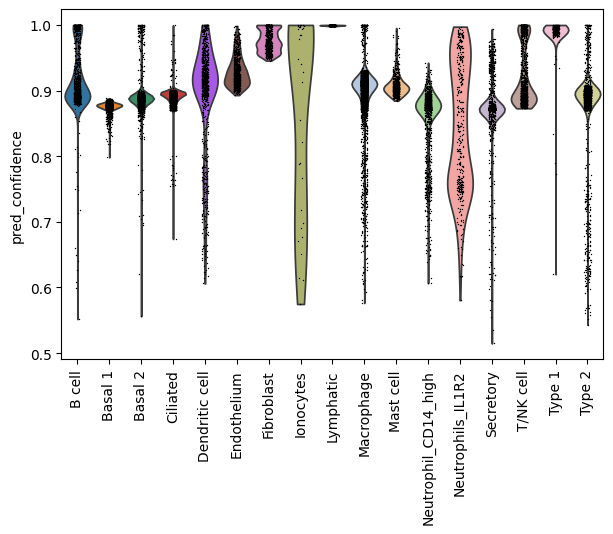

In [8]:
ax = sc.pl.violin(adata, keys="pred_confidence", groupby="pred_cell_type", rotation=90, show=False)
ax.get_legend().remove()
plt.tight_layout()
plt.show()

In [9]:
print(adata.obs["pred_cell_type"].isna().sum())
# combine labels and unlabels
adata.obs["pred_cell_type"] = (
    adata.obs["pred_cell_type"].astype("string")
    .fillna(adata.obs["semi_cell_type"].astype("string"))
)

print(adata.obs["pred_cell_type"].isna().sum())

6504
0


In [10]:
methods = ["X_supbiot"] # , "scBIOT_OT"
leiden_methods = [f'{method}_leiden' for method in methods]

for method, leiden_method in zip(methods, leiden_methods):
    sc.pp.neighbors(adata, use_rep=method)
    sc.tl.umap(adata)
    adata.obsm[f"X_umap_{method}"] = adata.obsm["X_umap"].copy()
    sc.tl.leiden(adata, key_added=leiden_method, resolution=0.8)

## Visualize
Compare batch and Leiden structure across embeddings in UMAP panels.

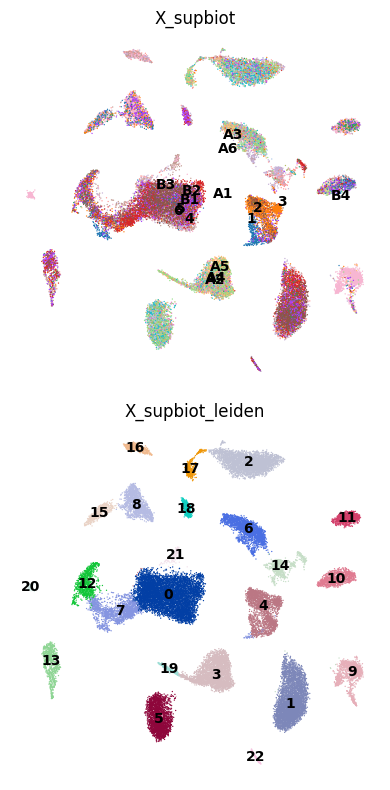

In [11]:
import matplotlib.pyplot as plt
import scanpy as sc


# 2 rows x len(methods) columns
fig, axes = plt.subplots(
    2,
    len(methods),
    figsize=(4 * len(methods), 8),
    squeeze=False  # ensures axes is a 2D array
)

for col, method in enumerate(methods):
    # 1) Top row (row=0): color by "batch"
    sc.pl.embedding(
        adata,
        basis=f"X_umap_{method}",  # The coordinates stored in adata.obsm["X_umap_{method}"]
        color="batch",            # Assume adata.obs["batch"] exists
        frameon=False,
        ax=axes[0, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        title=f"{method}"
    )

    # 2) Bottom row (row=1): color by the Leiden clusters for this method
    leiden_key = f"{method}_leiden"
    sc.pl.embedding(
        adata,
        basis=f"X_umap_{method}",
        color=leiden_key,         # Column in adata.obs
        frameon=False,
        ax=axes[1, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        # title=f"{method}"
    )

plt.tight_layout()
# fig.savefig("batch_and_leiden_per_embedding.pdf", dpi=300)
# plt.close(fig)


## Benchmark
fix the bug in the scib-metrics: change _graph_connectivity.py: <mask = labels == label> to <mask = (labels == label).to_numpy()>


In [12]:
bm = Benchmarker(
    adata, 
    batch_key="batch",
    label_key="cell_type",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),    
    embedding_obsm_keys=["X_pca", "X_supbiot"],
    n_jobs=-1
    
)
bm.benchmark()

Embeddings: 100%|██████████| 2/2 [00:48<00:00, 24.14s/it]


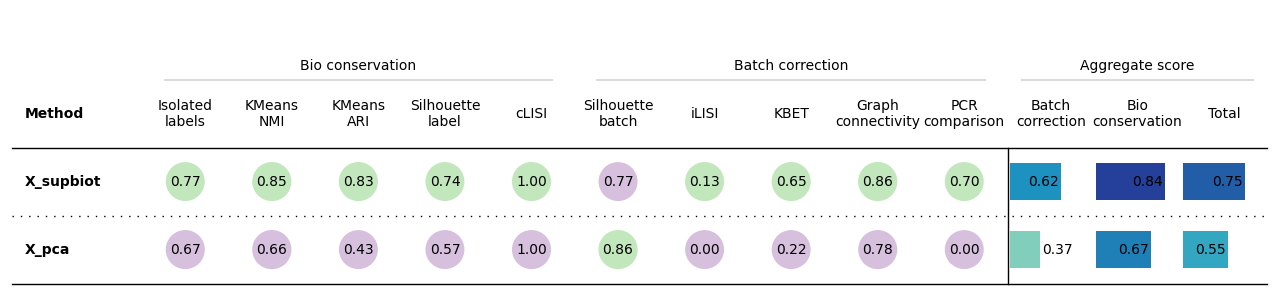

In [13]:
bm.plot_results_table(min_max_scale=False)